# MRL-POS Adapted for Hindi (Indo-Aryan)

Adapts the MRL-POS framework (Qi, Ali, Murat — Symmetry 2025) from Turkic agglutinative languages to Hindi's fusional morphology.

**Key adaptations:**
- Akshara-level (syllable) n-grams instead of character-level
- Shorter n-gram ranges (Hindi suffixes are 1–3 aksharas)
- Lower frequency thresholds
- Uses Hindi Universal Dependencies treebank (HDTB) for real data
- Context branch weighted heavier (postpositions are separate words)

In [3]:
# Cell 1: Install dependencies
!pip install -q transformers pytorch-crf seqeval regex conllu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import XLMRobertaModel, XLMRobertaTokenizer
from torchcrf import CRF
from collections import Counter
import numpy as np
import os
import regex

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Cell 2b: Mount Google Drive for persistent checkpoints
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CKPT_DIR = '/content/drive/MyDrive/mrl_pos_checkpoints'
    import os
    os.makedirs(CKPT_DIR, exist_ok=True)
    COLAB = True
    print(f"✓ Google Drive mounted. Checkpoints: {CKPT_DIR}")
except:
    COLAB = False
    CKPT_DIR = './'
    print("⚠ Not in Colab. Checkpoints will be saved locally.")

## 1. Devanagari Akshara Splitter

Hindi's script has **matras** (vowel diacritics) that attach to consonants. We must keep consonant+matra together as atomic units (aksharas) before generating n-grams.

```
लड़कियों → raw chars: ल, ड, ़, क, ि, य, ो, ं  (8 chars)
         → aksharas:  लड़, कि, यों              (3 aksharas)
```

In [5]:
# Cell 3: Devanagari akshara segmentation

def split_aksharas(word):
    """Split a Devanagari word into aksharas (orthographic syllables).

    Each akshara = consonant (+ nukta) (+ halant+consonant)* (+ matra/anusvara/visarga)
    Standalone vowels and non-Devanagari chars are kept as single units.
    """
    # Devanagari Unicode ranges:
    # Consonants: \u0915-\u0939
    # Nukta:      \u093C
    # Halant:     \u094D
    # Matras:     \u093E-\u094C
    # Anusvara:   \u0902, Visarga: \u0903, Chandrabindu: \u0901
    pattern = (
        r'[\u0915-\u0939][\u093C]?'           # base consonant (+ optional nukta)
        r'(?:[\u094D][\u0915-\u0939][\u093C]?)*'  # conjuncts (halant + consonant)
        r'[\u0901-\u0903\u093E-\u094D]*'      # trailing matras/anusvara/visarga
        r'|[\u0904-\u0914]'                    # standalone vowels
        r'|.'                                   # anything else (punctuation, digits)
    )
    return regex.findall(pattern, word)


# Demo: show akshara splits for Hindi words
demo_words = [
    ("लड़कियों", "girls (obl.pl)"),
    ("खाता", "eats (masc)"),
    ("खाती", "eats (fem)"),
    ("बच्चों", "children (obl.pl)"),
    ("पुस्तकालय", "library"),
    ("अच्छी", "good (fem)"),
]

print("Akshara segmentation demo:")
print("-" * 50)
for word, meaning in demo_words:
    aksharas = split_aksharas(word)
    print(f"  {word:15s} ({meaning:20s}) → {aksharas}")

Akshara segmentation demo:
--------------------------------------------------
  लड़कियों        (girls (obl.pl)      ) → ['ल', 'ड़', 'कि', 'यों']
  खाता            (eats (masc)         ) → ['खा', 'ता']
  खाती            (eats (fem)          ) → ['खा', 'ती']
  बच्चों          (children (obl.pl)   ) → ['ब', 'च्चों']
  पुस्तकालय       (library             ) → ['पु', 'स्त', 'का', 'ल', 'य']
  अच्छी           (good (fem)          ) → ['अ', 'च्छी']


## 2. Hindi Dynamic Affix Extractor

Adapted from paper Sec 3.3 with:
- **Akshara-level** n-grams (not character-level)
- **Shorter ranges**: 2–5 aksharas (Hindi suffixes are 1–3 aksharas)
- **Lower thresholds**: 20/40/80 (Hindi has fewer unique suffix forms)

In [6]:
# Cell 4: Hindi Dynamic Affix Extractor

class HindiAffixExtractor:
    """Devanagari-aware affix extractor adapted from MRL-POS Sec 3.3."""

    def __init__(self, max_affixes=8):
        self.max_affixes = max_affixes
        self.affix_freq = Counter()
        self.vocab = {}       # affix string -> index
        self.idx = 1          # 0 = pad

    # --- Adapted Sec 3.3.2: Shorter ranges for Hindi ---
    @staticmethod
    def _ngram_range(num_aksharas):
        """Hindi suffixes are shorter than Turkic, so use smaller windows."""
        if num_aksharas <= 4:
            return [2, 3]
        elif num_aksharas <= 7:
            return [2, 3, 4]
        else:
            return [3, 4, 5]

    # --- Adapted Sec 3.3.1: Boundary-marked akshara n-grams ---
    @staticmethod
    def _boundary_ngrams(word, n):
        """Generate n-grams over aksharas with boundary markers."""
        aksharas = split_aksharas(word)
        marked = ['<'] + aksharas + ['>']
        return [''.join(marked[i:i+n]) for i in range(len(marked) - n + 1)]

    # --- Adapted Sec 3.3.3: Lower thresholds for Hindi ---
    @staticmethod
    def _threshold(k):
        """Hindi has fewer unique suffixes, needs lower thresholds.
        k = number of aksharas in the n-gram."""
        if k <= 2:
            return 20    # very short: -ा, -ी, -े, -ों
        elif k <= 3:
            return 40    # short: -ता, -ती, -ने
        else:
            return 80    # longer: -ियों, -वाला

    def build_vocab(self, sentences):
        """Pass 1: count n-gram frequencies. Pass 2: filter by threshold."""
        for sent in sentences:
            for word in sent:
                num_aksharas = len(split_aksharas(word))
                for n in self._ngram_range(num_aksharas):
                    for ng in self._boundary_ngrams(word, n):
                        self.affix_freq[ng] += 1

        for affix, freq in self.affix_freq.items():
            k = len(affix)  # approximate length
            if freq >= self._threshold(k):
                self.vocab[affix] = self.idx
                self.idx += 1

        print(f"Hindi affix vocab: {len(self.vocab)} "
              f"(from {len(self.affix_freq)} candidates)")

    def extract(self, word):
        """Return affix indices for a word."""
        affixes = []
        num_aksharas = len(split_aksharas(word))
        for n in self._ngram_range(num_aksharas):
            for ng in self._boundary_ngrams(word, n):
                if ng in self.vocab:
                    affixes.append(self.vocab[ng])
        return affixes[:self.max_affixes]


# Demo: show boundary n-grams for Hindi words
extractor = HindiAffixExtractor()
print("\nHindi boundary n-gram demo:")
print("=" * 60)
for word, meaning in demo_words:
    aksharas = split_aksharas(word)
    print(f"\n  {word} ({meaning})")
    print(f"  Aksharas ({len(aksharas)}): {aksharas}")
    print(f"  N-gram range: {extractor._ngram_range(len(aksharas))}")
    for n in extractor._ngram_range(len(aksharas)):
        grams = extractor._boundary_ngrams(word, n)
        print(f"    {n}-grams: {grams}")


Hindi boundary n-gram demo:

  लड़कियों (girls (obl.pl))
  Aksharas (4): ['ल', 'ड़', 'कि', 'यों']
  N-gram range: [2, 3]
    2-grams: ['<ल', 'लड़', 'ड़कि', 'कियों', 'यों>']
    3-grams: ['<लड़', 'लड़कि', 'ड़कियों', 'कियों>']

  खाता (eats (masc))
  Aksharas (2): ['खा', 'ता']
  N-gram range: [2, 3]
    2-grams: ['<खा', 'खाता', 'ता>']
    3-grams: ['<खाता', 'खाता>']

  खाती (eats (fem))
  Aksharas (2): ['खा', 'ती']
  N-gram range: [2, 3]
    2-grams: ['<खा', 'खाती', 'ती>']
    3-grams: ['<खाती', 'खाती>']

  बच्चों (children (obl.pl))
  Aksharas (2): ['ब', 'च्चों']
  N-gram range: [2, 3]
    2-grams: ['<ब', 'बच्चों', 'च्चों>']
    3-grams: ['<बच्चों', 'बच्चों>']

  पुस्तकालय (library)
  Aksharas (5): ['पु', 'स्त', 'का', 'ल', 'य']
  N-gram range: [2, 3, 4]
    2-grams: ['<पु', 'पुस्त', 'स्तका', 'काल', 'लय', 'य>']
    3-grams: ['<पुस्त', 'पुस्तका', 'स्तकाल', 'कालय', 'लय>']
    4-grams: ['<पुस्तका', 'पुस्तकाल', 'स्तकालय', 'कालय>']

  अच्छी (good (fem))
  Aksharas (2): ['अ', 'च्छी']
  N-gram

## 3. Model Components (same architecture, Hindi-tuned)

The neural architecture stays the same as the original paper:
- Affix Embedding Module (Sec 3.3.4)
- Layer-Wise Attention Pooling (Sec 3.2)
- Dual-Gating Co-Attention (Sec 3.4)

Only the extractor preprocessing changes for Hindi.

In [7]:
# Cell 5: Affix Embedding Module (Sec 3.3.4 — unchanged from original)

class AffixEmbeddingModule(nn.Module):
    def __init__(self, affix_vocab_size, affix_dim=128,
                 hidden_dim=128, output_dim=768, max_affixes=8):
        super().__init__()
        self.max_affixes = max_affixes
        self.embedding = nn.Embedding(affix_vocab_size, affix_dim, padding_idx=0)
        self.pos_encoding = nn.Embedding(max_affixes, affix_dim)
        self.bilstm = nn.LSTM(affix_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attn_vector = nn.Linear(hidden_dim * 2, 1, bias=False)
        self.proj = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, affix_ids):
        B, S, M = affix_ids.shape
        flat = affix_ids.view(B * S, M)
        positions = torch.arange(M, device=affix_ids.device).unsqueeze(0).expand(B * S, -1)
        emb = self.embedding(flat) + self.pos_encoding(positions)
        H, _ = self.bilstm(emb)
        scores = self.attn_vector(H).squeeze(-1)
        mask = (flat == 0)
        scores = scores.masked_fill(mask, -1e9)
        beta = F.softmax(scores, dim=-1)
        H_aff = (beta.unsqueeze(-1) * H).sum(dim=1)
        return self.proj(H_aff).view(B, S, -1)


# Cell 5b: Layer-Wise Attention Pooling (Sec 3.2 — unchanged)

class LayerWiseAttentionPooling(nn.Module):
    def __init__(self, hidden_dim=768, num_layers=12):
        super().__init__()
        self.layer_weights = nn.Linear(hidden_dim, 1)

    def forward(self, all_hidden_states):
        stacked = torch.stack(all_hidden_states[1:], dim=2)
        scores = self.layer_weights(stacked).squeeze(-1)
        alpha = F.softmax(scores, dim=-1)
        return (alpha.unsqueeze(-1) * stacked).sum(dim=2)


# Cell 5c: Dual-Gating Co-Attention (Sec 3.4 — unchanged)

class DualGatingCoAttention(nn.Module):
    def __init__(self, hidden_dim=768):
        super().__init__()
        d = hidden_dim
        self.W_a2c = nn.Linear(2 * d, d)
        self.W_c2a = nn.Linear(2 * d, d)
        self.linear_fuse = nn.Linear(2 * d, d)

    def forward(self, H_cw, H_aw):
        concat = torch.cat([H_cw, H_aw], dim=-1)
        g_a2c = torch.sigmoid(self.W_a2c(concat))
        H_cw_gated = g_a2c * H_cw
        g_c2a = torch.sigmoid(self.W_c2a(concat))
        H_aw_gated = g_c2a * H_aw
        fused = torch.cat([H_cw_gated, H_aw_gated], dim=-1)
        return self.linear_fuse(fused)


print("All model components defined.")

All model components defined.


In [8]:
# Cell 6: Full MRL-POS Model for Hindi

class MRLPOS_Hindi(nn.Module):
    def __init__(self, affix_vocab_size, num_tags, affix_dim=128,
                 hidden_dim=768, max_affixes=8):
        super().__init__()
        self.num_tags = num_tags
        self.max_affixes = max_affixes

        self.xlmr = XLMRobertaModel.from_pretrained(
            "xlm-roberta-base", output_hidden_states=True
        )
        self.layer_pooling = LayerWiseAttentionPooling(hidden_dim)
        self.affix_module = AffixEmbeddingModule(
            affix_vocab_size, affix_dim=affix_dim,
            hidden_dim=affix_dim, output_dim=hidden_dim,
            max_affixes=max_affixes
        )
        self.co_attention = DualGatingCoAttention(hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_tags)
        self.crf = CRF(num_tags, batch_first=True)

    def forward(self, input_ids, attention_mask, affix_ids, tags=None):
        xlmr_out = self.xlmr(input_ids=input_ids, attention_mask=attention_mask)
        H_cw = self.layer_pooling(xlmr_out.hidden_states)
        H_aw = self.affix_module(affix_ids)
        H_fused = self.co_attention(H_cw, H_aw)
        emissions = self.classifier(H_fused)

        if tags is not None:
            return -self.crf(emissions, tags, mask=attention_mask.bool())
        else:
            return self.crf.decode(emissions, mask=attention_mask.bool())


print("MRLPOS_Hindi model defined.")

MRLPOS_Hindi model defined.


## 4. Hindi Demo Data

Synthetic Hindi sentences with POS tags (Universal Dependencies tagset).
Replace with the **Hindi HDTB treebank** for real experiments.

In [9]:
# Cell 7: Hindi tag set and demo data

# Universal Dependencies POS tags (used by Hindi HDTB treebank)
TAG2IDX = {
    "PAD": 0,
    "NOUN": 1, "VERB": 2, "ADJ": 3, "ADV": 4, "ADP": 5,
    "PRON": 6, "DET": 7, "NUM": 8, "CONJ": 9, "PART": 10,
    "AUX": 11, "PUNCT": 12, "PROPN": 13, "SCONJ": 14, "X": 15
}
IDX2TAG = {v: k for k, v in TAG2IDX.items()}
NUM_TAGS = len(TAG2IDX)

# Synthetic Hindi sentences for demo
# Format: ([words], [UD POS tags])
HINDI_DEMO = [
    # "The boy eats food."
    (["लड़का", "खाना", "खाता", "है", "।"],
     ["NOUN", "NOUN", "VERB", "AUX", "PUNCT"]),

    # "The girl went to school."
    (["लड़की", "स्कूल", "गई", "।"],
     ["NOUN", "NOUN", "VERB", "PUNCT"]),

    # "Children play in the garden." (oblique plural + postposition)
    (["बच्चों", "ने", "बगीचे", "में", "खेला", "।"],
     ["NOUN", "ADP", "NOUN", "ADP", "VERB", "PUNCT"]),

    # "She reads a good book."
    (["वह", "अच्छी", "किताब", "पढ़ती", "है", "।"],
     ["PRON", "ADJ", "NOUN", "VERB", "AUX", "PUNCT"]),

    # "Ram went to Delhi yesterday."
    (["राम", "कल", "दिल्ली", "गया", "।"],
     ["PROPN", "ADV", "PROPN", "VERB", "PUNCT"]),

    # "I will write a letter."
    (["मैं", "पत्र", "लिखूँगा", "।"],
     ["PRON", "NOUN", "VERB", "PUNCT"]),

    # "Those girls are singing."
    (["वे", "लड़कियाँ", "गा", "रही", "हैं", "।"],
     ["DET", "NOUN", "VERB", "AUX", "AUX", "PUNCT"]),

    # "He quickly ran home."
    (["वह", "तेज़ी", "से", "घर", "भागा", "।"],
     ["PRON", "NOUN", "ADP", "NOUN", "VERB", "PUNCT"]),

    # "The big dog sat."
    (["बड़ा", "कुत्ता", "बैठा", "।"],
     ["ADJ", "NOUN", "VERB", "PUNCT"]),

    # "We will go together."
    (["हम", "साथ", "चलेंगे", "।"],
     ["PRON", "ADV", "VERB", "PUNCT"]),
]

print(f"Demo sentences: {len(HINDI_DEMO)}")
print(f"Tags: {list(TAG2IDX.keys())}")
print(f"\nSample sentence:")
for w, t in zip(HINDI_DEMO[2][0], HINDI_DEMO[2][1]):
    print(f"  {w:10s} → {t}")

Demo sentences: 10
Tags: ['PAD', 'NOUN', 'VERB', 'ADJ', 'ADV', 'ADP', 'PRON', 'DET', 'NUM', 'CONJ', 'PART', 'AUX', 'PUNCT', 'PROPN', 'SCONJ', 'X']

Sample sentence:
  बच्चों     → NOUN
  ने         → ADP
  बगीचे      → NOUN
  में        → ADP
  खेला       → VERB
  ।          → PUNCT


In [10]:
# Cell 8: Build affix vocab from demo data

extractor = HindiAffixExtractor(max_affixes=8)

# For demo: register all n-grams (skip frequency filtering on tiny data)
all_words = [w for sent, _ in HINDI_DEMO for w in sent]
for word in all_words:
    num_aksharas = len(split_aksharas(word))
    for n in extractor._ngram_range(num_aksharas):
        for ng in extractor._boundary_ngrams(word, n):
            if ng not in extractor.vocab:
                extractor.vocab[ng] = extractor.idx
                extractor.idx += 1

AFFIX_VOCAB_SIZE = extractor.idx
print(f"Demo affix vocab size: {AFFIX_VOCAB_SIZE}")

# Show what affixes look like for a few words
print("\nAffix extraction examples:")
print("-" * 50)
for word in ["लड़कियों", "खाता", "बच्चों", "पढ़ती", "लिखूँगा"]:
    ids = extractor.extract(word)
    # Reverse lookup
    idx_to_affix = {v: k for k, v in extractor.vocab.items()}
    affix_strs = [idx_to_affix.get(i, '?') for i in ids]
    print(f"  {word:12s} → {affix_strs}")

Demo affix vocab size: 181

Affix extraction examples:
--------------------------------------------------
  लड़कियों     → ['<ल', 'लड़', 'ड़कि', '<लड़', 'लड़कि']
  खाता         → ['<खा', 'खाता', 'ता>', '<खाता', 'खाता>']
  बच्चों       → ['<ब', 'बच्चों', 'च्चों>', '<बच्चों', 'बच्चों>']
  पढ़ती        → ['<प', 'पढ़', 'ढ़ती', 'ती>', '<पढ़', 'पढ़ती', 'ढ़ती>']
  लिखूँगा      → ['<लि', 'लिखूँ', 'खूँगा', 'गा>', '<लिखूँ', 'लिखूँगा', 'खूँगा>']


In [11]:
# Cell 9: Dataset class (handles XLM-R subword ↔ word alignment)

class HindiPOSDataset(Dataset):
    def __init__(self, data, tokenizer, affix_extractor, tag2idx, max_len=64):
        self.data = data
        self.tokenizer = tokenizer
        self.extractor = affix_extractor
        self.tag2idx = tag2idx
        self.max_len = max_len
        self.max_affixes = affix_extractor.max_affixes

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        words, tags = self.data[idx]

        encoding = self.tokenizer(
            words, is_split_into_words=True,
            padding="max_length", truncation=True,
            max_length=self.max_len, return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)
        word_ids = encoding.word_ids()

        aligned_tags = []
        aligned_affixes = []
        prev_word_id = None

        for i, wid in enumerate(word_ids):
            if wid is None:
                aligned_tags.append(self.tag2idx["PAD"])
                aligned_affixes.append([0] * self.max_affixes)
            elif wid != prev_word_id:
                aligned_tags.append(self.tag2idx[tags[wid]])
                affix_ids = self.extractor.extract(words[wid])
                affix_ids = affix_ids + [0] * (self.max_affixes - len(affix_ids))
                aligned_affixes.append(affix_ids)
            else:
                aligned_tags.append(self.tag2idx["PAD"])
                aligned_affixes.append([0] * self.max_affixes)
            prev_word_id = wid

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "affix_ids": torch.tensor(aligned_affixes, dtype=torch.long),
            "tags": torch.tensor(aligned_tags, dtype=torch.long),
        }


tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")
dataset = HindiPOSDataset(HINDI_DEMO, tokenizer, extractor, TAG2IDX, max_len=32)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

batch = next(iter(dataloader))
print("Batch shapes:")
for k, v in batch.items():
    print(f"  {k}: {v.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Batch shapes:
  input_ids: torch.Size([4, 32])
  attention_mask: torch.Size([4, 32])
  affix_ids: torch.Size([4, 32, 8])
  tags: torch.Size([4, 32])


## 5. Training

In [ ]:
# Cell 10: Instantiate model and optimizer for demo training
model = MRLPOS_Hindi(
    affix_vocab_size=AFFIX_VOCAB_SIZE,
    num_tags=NUM_TAGS,
).to(device)

optimizer = torch.optim.AdamW([
    {"params": list(model.xlmr.parameters()), "lr": 3e-5},
    {"params": [p for n, p in model.named_parameters()
                if not n.startswith("xlmr.")], "lr": 1e-3},
])

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Affix vocab size: {AFFIX_VOCAB_SIZE}")
print(f"Num tags: {NUM_TAGS}")

In [ ]:
# Cell 11: Training loop (5 epochs on demo data)

NUM_EPOCHS = 5

# Try loading checkpoint if it exists
ckpt_path = os.path.join(CKPT_DIR, "mrlpos_hindi_demo_best.pt")
start_epoch = 0
best_f1_loaded = 0
if os.path.exists(ckpt_path):
    print(f"Loading checkpoint from {ckpt_path}...")
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt.get('epoch', 0)
    best_f1_loaded = ckpt.get('best_f1', 0)
    print(f"  Resumed from epoch {start_epoch}, Best F1={best_f1_loaded:.4f}")

model.train()
for epoch in range(start_epoch, NUM_EPOCHS):
    total_loss = 0
    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        affix_ids = batch["affix_ids"].to(device)
        tags = batch["tags"].to(device)

        optimizer.zero_grad()
        loss = model(input_ids, attention_mask, affix_ids, tags=tags)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {total_loss / len(dataloader):.4f}")

## 6. Inference

In [14]:
# Cell 12: Run inference on a test sentence

model.eval()

test_words = ["लड़की", "अच्छी", "किताब", "पढ़ती", "है", "।"]
test_sample = HindiPOSDataset(
    [(test_words, ["NOUN"] * len(test_words))],
    tokenizer, extractor, TAG2IDX, max_len=32
)[0]

with torch.no_grad():
    input_ids = test_sample["input_ids"].unsqueeze(0).to(device)
    attn_mask = test_sample["attention_mask"].unsqueeze(0).to(device)
    affix_ids = test_sample["affix_ids"].unsqueeze(0).to(device)
    predicted = model(input_ids, attn_mask, affix_ids)[0]

encoding = tokenizer(test_words, is_split_into_words=True,
                     padding="max_length", max_length=32, return_tensors="pt")
word_ids = encoding.word_ids()

print("Predictions:")
print("-" * 35)
prev_wid = None
for i, wid in enumerate(word_ids):
    if wid is not None and wid != prev_wid and i < len(predicted):
        tag = IDX2TAG.get(predicted[i], "?")
        print(f"  {test_words[wid]:12s} → {tag}")
    prev_wid = wid

Predictions:
-----------------------------------
  लड़की        → NOUN
  अच्छी        → ADJ
  किताब        → NOUN
  पढ़ती        → VERB
  है           → AUX
  ।            → PUNCT


## 7. Visualize Gate Activations

See whether the model leans on **affix** or **context** for different Hindi word types:
- Postpositions (ने, में, से) → should lean **context** (they're function words)
- Inflected verbs (खाता, पढ़ती) → should use **both** (suffix encodes gender/tense)
- Nouns with case (बच्चों, लड़कियों) → should lean **affix** (suffix encodes case+number)

/tmp/ipykernel_5500/687841461.py:62: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5500/687841461.py:62: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_5500/687841461.py:62: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5500/687841461.py:62: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5500/687841461.py:62: UserWarning: Glyph 2379 (\N{DEVANAGARI VOWEL SIGN O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5500/687841461.py:62: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5500/687841461.py:62: UserWarning: Glyph 2344 (\N{DEVANAGARI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

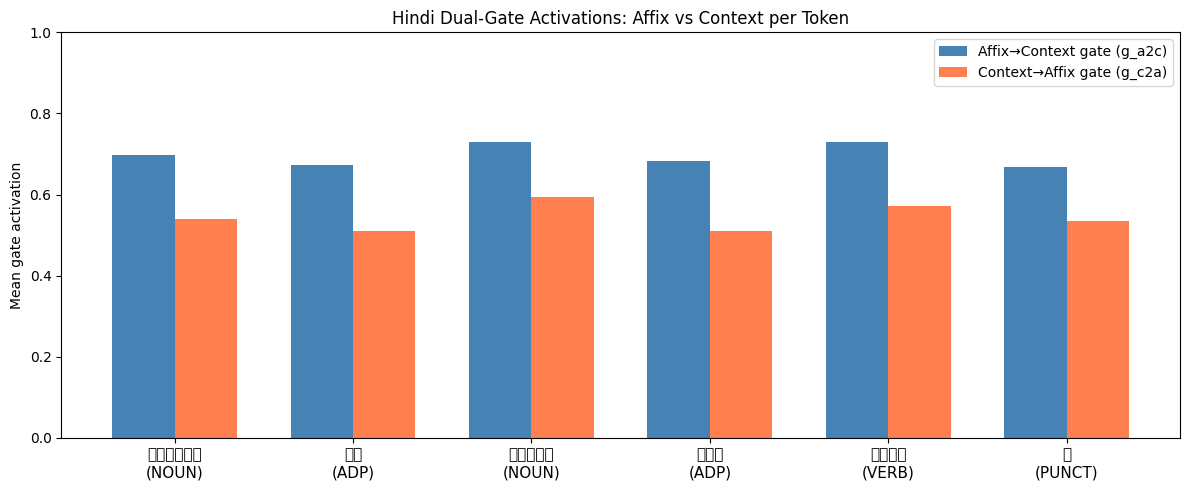

In [15]:
# Cell 13: Gate activation visualization
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

model.eval()
viz_words = ["बच्चों", "ने", "बगीचे", "में", "खेला", "।"]
viz_tags  = ["NOUN", "ADP", "NOUN", "ADP", "VERB", "PUNCT"]

viz_sample = HindiPOSDataset(
    [(viz_words, viz_tags)],
    tokenizer, extractor, TAG2IDX, max_len=32
)[0]

gate_vals = {}
def hook_gates(module, input, output):
    H_cw, H_aw = input
    concat = torch.cat([H_cw, H_aw], dim=-1)
    gate_vals["g_a2c"] = torch.sigmoid(module.W_a2c(concat)).detach().cpu()
    gate_vals["g_c2a"] = torch.sigmoid(module.W_c2a(concat)).detach().cpu()

hook = model.co_attention.register_forward_hook(hook_gates)

with torch.no_grad():
    _ = model(
        viz_sample["input_ids"].unsqueeze(0).to(device),
        viz_sample["attention_mask"].unsqueeze(0).to(device),
        viz_sample["affix_ids"].unsqueeze(0).to(device),
    )
hook.remove()

# Get word-aligned positions
enc = tokenizer(viz_words, is_split_into_words=True,
                padding="max_length", max_length=32, return_tensors="pt")
wids = enc.word_ids()
word_positions = []
prev = None
for i, wid in enumerate(wids):
    if wid is not None and wid != prev:
        word_positions.append(i)
    prev = wid

ctx_strengths = [gate_vals["g_a2c"][0, p].mean().item() for p in word_positions]
afx_strengths = [gate_vals["g_c2a"][0, p].mean().item() for p in word_positions]

# Labels: word + POS
labels = [f"{w}\n({t})" for w, t in zip(viz_words, viz_tags)]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(viz_words))
width = 0.35
ax.bar(x - width/2, ctx_strengths, width,
       label="Affix→Context gate (g_a2c)", color="steelblue")
ax.bar(x + width/2, afx_strengths, width,
       label="Context→Affix gate (g_c2a)", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("Mean gate activation")
ax.set_title("Hindi Dual-Gate Activations: Affix vs Context per Token")
ax.legend(loc="upper right")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 8. Load Real Data: Hindi HDTB Treebank

The [Hindi Universal Dependencies treebank (HDTB)](https://universaldependencies.org/) has ~16K annotated sentences. Here's how to load it for real training.

In [16]:
# Cell 14: Load Hindi HDTB from Universal Dependencies

import os
import conllu

def download_hdtb():
    """Download Hindi HDTB treebank from Universal Dependencies."""
    ud_url = "https://raw.githubusercontent.com/UniversalDependencies/UD_Hindi-HDTB/master"
    splits = {
        "train": "hi_hdtb-ud-train.conllu",
        "dev":   "hi_hdtb-ud-dev.conllu",
        "test":  "hi_hdtb-ud-test.conllu",
    }
    os.makedirs("hdtb", exist_ok=True)
    for split, fname in splits.items():
        path = f"hdtb/{fname}"
        if not os.path.exists(path):
            print(f"Downloading {split}...")
            !wget -q {ud_url}/{fname} -O {path}
    return splits


def load_conllu(path):
    """Parse a CoNLL-U file into (words, tags) pairs."""
    data = []
    with open(path, 'r') as f:
        for sent in conllu.parse(f.read()):
            words = [tok["form"] for tok in sent]
            tags = [tok["upos"] for tok in sent]
            data.append((words, tags))
    return data


# Download and load
splits = download_hdtb()
train_data = load_conllu(f"hdtb/{splits['train']}")
dev_data   = load_conllu(f"hdtb/{splits['dev']}")
test_data  = load_conllu(f"hdtb/{splits['test']}")

print(f"Train: {len(train_data)} sentences")
print(f"Dev:   {len(dev_data)} sentences")
print(f"Test:  {len(test_data)} sentences")
print(f"\nSample: {train_data[0][0][:6]}")
print(f"Tags:   {train_data[0][1][:6]}")

Train: 13306 sentences
Dev:   1659 sentences
Test:  1684 sentences

Sample: ['यह', 'एशिया', 'की', 'सबसे', 'बड़ी', 'मस्जिदों']
Tags:   ['DET', 'PROPN', 'ADP', 'ADV', 'ADJ', 'NOUN']


In [17]:
# Cell 15: Build real affix vocab from HDTB training data

real_extractor = HindiAffixExtractor(max_affixes=8)
train_words = [sent for sent, _ in train_data]
real_extractor.build_vocab(train_words)

# Show top affixes by frequency
print("\nTop 20 Hindi affixes by frequency:")
print("-" * 40)
sorted_affixes = sorted(real_extractor.affix_freq.items(),
                        key=lambda x: -x[1])
for affix, freq in sorted_affixes[:20]:
    in_vocab = "✓" if affix in real_extractor.vocab else "✗"
    print(f"  {affix:10s}  freq={freq:5d}  {in_vocab}")

Hindi affix vocab: 3452 (from 60948 candidates)

Top 20 Hindi affixes by frequency:
----------------------------------------
  र>          freq=20660  ✓
  के>         freq=14472  ✓
  <के         freq=13061  ✓
  <के>        freq=12712  ✓
  ने>         freq=12418  ✓
  <।          freq=12160  ✓
  ।>          freq=12160  ✓
  <।>         freq=12160  ✓
  <क          freq= 9403  ✓
  न>          freq= 9301  ✓
  में>        freq= 8903  ✓
  की>         freq= 8532  ✓
  <में        freq= 8431  ✓
  <में>       freq= 8421  ✓
  <अ          freq= 8158  ✓
  <की         freq= 7583  ✓
  <की>        freq= 7475  ✓
  <को         freq= 7071  ✓
  <है         freq= 6969  ✓
  <प          freq= 6947  ✓


In [ ]:
# Cell 16: Full training on HDTB (improved hyperparameters)

from sklearn.metrics import f1_score as sklearn_f1, accuracy_score, classification_report
from transformers import get_linear_schedule_with_warmup

# Update tag set from actual HDTB data
all_tags = set()
for _, tags in train_data:
    all_tags.update(tags)
REAL_TAG2IDX = {"PAD": 0}
for i, t in enumerate(sorted(all_tags), 1):
    REAL_TAG2IDX[t] = i
REAL_IDX2TAG = {v: k for k, v in REAL_TAG2IDX.items()}
print(f"Tag set ({len(REAL_TAG2IDX)}): {REAL_TAG2IDX}")

# --- Hyperparameters (tuned for stability) ---
BATCH_SIZE = 64          # larger batch = more stable gradients
MAX_EPOCHS = 30
PATIENCE = 5             # give model more room to recover
ENCODER_LR = 1e-5        # slower fine-tuning for XLM-R (was 3e-5)
HEAD_LR = 1e-3           # affix module + co-attention + classifier
WARMUP_RATIO = 0.1       # 10% warmup steps

# Create datasets
train_ds = HindiPOSDataset(train_data, tokenizer, real_extractor, REAL_TAG2IDX, max_len=128)
dev_ds   = HindiPOSDataset(dev_data, tokenizer, real_extractor, REAL_TAG2IDX, max_len=128)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
dev_dl   = DataLoader(dev_ds, batch_size=BATCH_SIZE)

# Model
real_model = MRLPOS_Hindi(
    affix_vocab_size=real_extractor.idx,
    num_tags=len(REAL_TAG2IDX),
).to(device)

optimizer = torch.optim.AdamW([
    {"params": list(real_model.xlmr.parameters()), "lr": ENCODER_LR},
    {"params": [p for n, p in real_model.named_parameters()
                if not n.startswith("xlmr.")], "lr": HEAD_LR},
])

# Linear warmup + decay scheduler
total_steps = len(train_dl) * MAX_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"Training steps: {total_steps}, Warmup: {warmup_steps}")
print(f"Encoder LR: {ENCODER_LR}, Head LR: {HEAD_LR}")
print(f"Batch size: {BATCH_SIZE}, Patience: {PATIENCE}")

# --- Evaluation function using sklearn (TOKEN-LEVEL, not span-level) ---
def evaluate(model, dataloader, idx2tag):
    """Compute token-level accuracy and macro F1, excluding PAD tokens."""
    model.eval()
    all_preds = []
    all_golds = []

    with torch.no_grad():
        for batch in dataloader:
            preds = model(
                batch["input_ids"].to(device),
                batch["attention_mask"].to(device),
                batch["affix_ids"].to(device),
            )
            tags = batch["tags"]
            mask = batch["attention_mask"]

            for b in range(len(preds)):
                for i, (pred_idx, gold, m) in enumerate(
                    zip(preds[b], tags[b], mask[b])
                ):
                    if m.item() == 1 and gold.item() != 0:
                        all_preds.append(pred_idx)
                        all_golds.append(gold.item())

    acc = accuracy_score(all_golds, all_preds)
    f1 = sklearn_f1(all_golds, all_preds, average="macro", zero_division=0)

    return acc, f1

# Try loading checkpoint if it exists
ckpt_path = f"{CKPT_DIR}/mrlpos_hindi_best.pt"
start_epoch = 0
best_f1 = 0
best_state = {k: v.cpu().clone() for k, v in real_model.state_dict().items()}

if os.path.exists(ckpt_path):
    print(f"Loading checkpoint from {ckpt_path}...")
    ckpt = torch.load(ckpt_path, map_location=device)
    real_model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt.get('epoch', 0)
    best_f1 = ckpt.get('best_f1', 0)
    best_state = ckpt['model_state_dict']
    # Advance scheduler to match resumed epoch
    for _ in range(start_epoch * len(train_dl)):
        scheduler.step()
    print(f"  Resumed from epoch {start_epoch}, Best F1={best_f1:.4f}")

# --- Training loop with early stopping ---
no_improve = 0

for epoch in range(start_epoch, MAX_EPOCHS):
    real_model.train()
    total_loss = 0
    for batch in train_dl:
        optimizer.zero_grad()
        loss = real_model(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["affix_ids"].to(device),
            tags=batch["tags"].to(device),
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(real_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_dl)
    acc, f1 = evaluate(real_model, dev_dl, REAL_IDX2TAG)
    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | "
          f"Dev Acc: {acc:.4f} | Dev Macro-F1: {f1:.4f} | LR: {current_lr:.2e}")

    if f1 > best_f1:
        best_f1 = f1
        no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in real_model.state_dict().items()}
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': best_state,
            'optimizer_state_dict': optimizer.state_dict(),
            'best_f1': best_f1,
        }, ckpt_path)
        print(f"  -> Saved checkpoint (F1={best_f1:.4f})")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}. Best Macro-F1: {best_f1:.4f}")
            break

# --- Final report on dev set ---
print("\n" + "=" * 50)
print("Final classification report on dev set:")
print("=" * 50)
real_model.load_state_dict(best_state)
real_model.to(device)
real_model.eval()

all_preds, all_golds = [], []
with torch.no_grad():
    for batch in dev_dl:
        preds = real_model(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            batch["affix_ids"].to(device),
        )
        for b in range(len(preds)):
            for pred_idx, gold, m in zip(preds[b], batch["tags"][b], batch["attention_mask"][b]):
                if m.item() == 1 and gold.item() != 0:
                    all_preds.append(REAL_IDX2TAG[pred_idx])
                    all_golds.append(REAL_IDX2TAG[gold.item()])

real_tags = sorted([t for t in REAL_TAG2IDX.keys() if t != "PAD"])
print(classification_report(all_golds, all_preds, labels=real_tags, zero_division=0))

## 10. Summary: What Changed for Hindi

| Component | Turkic (Original) | Hindi (This notebook) |
|---|---|---|
| **Script unit** | Character | Akshara (syllable) |
| **N-gram range** | 3–7 chars | 2–5 aksharas |
| **Freq threshold** | 50 / 100 | 20 / 40 / 80 |
| **Tag set** | Custom 12 tags | UD 16 tags |
| **Real data** | POS_ukg (custom) | HDTB treebank (UD) |
| **Neural arch** | Unchanged | Unchanged |
| **Case marking** | Suffix on noun | Separate postposition (ADP) |